# 05 -- Calculus review: derivative, integral, Taylor, gradient

| question | answer |
|---|---|
| What physics problem? | Velocity is the rate of change of position; work is the integral of force. |
| What mathematics? | Limits, the derivative, the definite integral, the fundamental theorem, Taylor series, the gradient. |
| What algorithm? | Finite-difference differentiation and trapezoid/Simpson integration; automatic differentiation. |
| What software? | SymPy for exact calculus; NumPy/SciPy for numerics; optional PyTorch autograd. |
| What experiment? | A position sensor is differentiated to velocity; a power meter is integrated to energy. |
| What engineering application? | Firmware differences an ADC stream; a running sum integrates it; autograd is backpropagation. |

This notebook follows the repository template: English explanation, mathematical derivation,
dimensions and SI units, SymPy derivation, NumPy implementation, Pandas tables, Matplotlib plots,
optional PyTorch, exercises, and engineering applications. It reuses the `physkit` package and the
results of earlier chapters.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## English explanation

Calculus turns a signal into its rate of change (the **derivative**) and accumulates a rate into
a total (the **integral**); the **fundamental theorem** says these undo each other. The **Taylor
series** approximates a smooth function by a polynomial near a point -- the basis of every numerical
method that follows. In three dimensions the **gradient** points uphill on a scalar field. This
chapter fixes the exact results (SymPy) and their numerical counterparts (NumPy), building on the
floating-point care of chapter 00.

Subject-verb-object: the derivative measures the rate; the integral accumulates the total; the
gradient points uphill.

## Mathematical derivation

The derivative is the limit $f'(x)=\lim_{h\to0}\frac{f(x+h)-f(x)}{h}$; the central difference
$\frac{f(x+h)-f(x-h)}{2h}$ approximates it with error $O(h^2)$. The definite integral is the limit of
Riemann sums, and the **fundamental theorem** gives $\int_a^b f'(x)\,dx=f(b)-f(a)$. Taylor's theorem
writes $f(x)=\sum_{n\ge0}\frac{f^{(n)}(a)}{n!}(x-a)^n$; truncating gives a polynomial approximant. The
gradient of $f(x,y)$ is $\nabla f=(\partial_x f,\partial_y f)$.

## Dimensions and SI units

Differentiating with respect to time divides the dimension by time, integrating over time
multiplies by it. So $\frac{d}{dt}[\text{position}]$ is a velocity and $\frac{d}{dt}[\text{velocity}]$
an acceleration, while $\int[\text{power}]\,dt$ is an energy. `physkit.units` confirms the bookkeeping.

In [2]:
x = U.LENGTH; t = U.TIME
velocity = x / t; acceleration = velocity / t
print("d(position)/dt ->", velocity, "(VELOCITY:", velocity == U.VELOCITY, ")")
print("d(velocity)/dt ->", acceleration, "(ACCELERATION:", acceleration == U.ACCELERATION, ")")
energy = U.POWER * U.TIME                         # integral of power over time
print("int(power) dt ->", energy, "(ENERGY:", energy == U.ENERGY, ")")
assert velocity == U.VELOCITY and energy == U.ENERGY

d(position)/dt -> L^1 T^-1 (VELOCITY: True )
d(velocity)/dt -> L^1 T^-2 (ACCELERATION: True )
int(power) dt -> L^2 M^1 T^-2 (ENERGY: True )


## SymPy derivation

SymPy differentiates and integrates exactly, and verifies the fundamental theorem and a Taylor
expansion.

In [3]:
xs = sp.symbols('x', real=True)
f = sp.sin(xs) * sp.exp(xs)
fp = sp.diff(f, xs)
print("d/dx [sin(x) e^x] =", sp.simplify(fp))
# fundamental theorem: integral of f' from 0 to 1 equals f(1) - f(0)
ftc = sp.integrate(fp, (xs, 0, 1)) - (f.subs(xs, 1) - f.subs(xs, 0))
assert sp.simplify(ftc) == 0
print("fundamental theorem verified: int_0^1 f' dx = f(1) - f(0)")
# Taylor series of sin about 0
print("sin(x) =", sp.series(sp.sin(xs), xs, 0, 8))

d/dx [sin(x) e^x] = sqrt(2)*exp(x)*sin(x + pi/4)
fundamental theorem verified: int_0^1 f' dx = f(1) - f(0)
sin(x) = x - x**3/6 + x**5/120 - x**7/5040 + O(x**8)


## NumPy implementation

The central-difference derivative and the trapezoid integral, checked against the exact SymPy
results. As in chapter 00, too small an $h$ reintroduces rounding error.

In [4]:
fnum = lambda x: np.sin(x)*np.exp(x)
fp_exact = lambda x: np.exp(x)*(np.sin(x)+np.cos(x))
x0, h = 1.3, 1e-5
central = (fnum(x0+h) - fnum(x0-h)) / (2*h)
print(f"central diff f'(1.3) = {central:.8f} | exact = {fp_exact(x0):.8f}")

# trapezoid integral of f' from 0 to 1 should recover f(1)-f(0)
xg = np.linspace(0, 1, 2001)
I = np.trapezoid(fp_exact(xg), xg)
print(f"trapezoid int f' [0,1] = {I:.6f} | f(1)-f(0) = {fnum(1)-fnum(0):.6f}")

central diff f'(1.3) = 4.51711340 | exact = 4.51711340
trapezoid int f' [0,1] = 2.287355 | f(1)-f(0) = 2.287355


## Pandas tables

Integration error falls with the number of panels: trapezoid as $O(N^{-2})$, Simpson as
$O(N^{-4})$.

In [5]:
def simpson(y, x):
    n = len(x) - 1                       # number of panels (even)
    h = (x[-1] - x[0]) / n
    return h/3 * (y[0] + y[-1] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-1:2]))

exact = fnum(1) - fnum(0)
rows = []
for N in (10, 20, 40, 80, 160):
    xg = np.linspace(0, 1, N+1)
    y = fp_exact(xg)
    rows.append({"N": N, "trapezoid_err": abs(np.trapezoid(y, xg) - exact),
                 "simpson_err": abs(simpson(y, xg) - exact)})
df = pd.DataFrame(rows)
print(df.to_string(index=False))

  N  trapezoid_err  simpson_err
 10       0.000782 5.080506e-06
 20       0.000195 3.176494e-07
 40       0.000049 1.985491e-08
 80       0.000012 1.240960e-09
160       0.000003 7.756018e-11


## Matplotlib plots

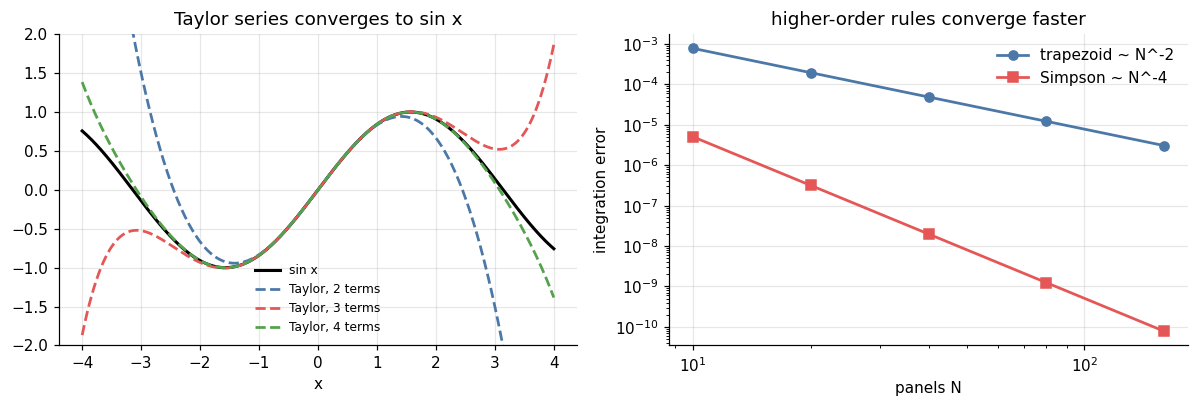

In [6]:
import math
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
xg = np.linspace(-4, 4, 400)
ax[0].plot(xg, np.sin(xg), "k", lw=2, label="sin x")
for terms in (2, 3, 4):                          # partial sums of the sine Taylor series
    approx = sum(((-1)**k)/math.factorial(2*k+1) * xg**(2*k+1) for k in range(terms))
    ax[0].plot(xg, approx, "--", label=f"Taylor, {terms} terms")
ax[0].set_ylim(-2, 2); ax[0].set_title("Taylor series converges to sin x"); ax[0].legend(fontsize=8)
ax[0].set_xlabel("x")
ax[1].loglog(df["N"], df["trapezoid_err"], "o-", label="trapezoid ~ N^-2")
ax[1].loglog(df["N"], df["simpson_err"], "s-", label="Simpson ~ N^-4")
ax[1].set_xlabel("panels N"); ax[1].set_ylabel("integration error"); ax[1].legend()
ax[1].set_title("higher-order rules converge faster")
plt.tight_layout(); plt.show()

## PyTorch (optional)

Automatic differentiation computes exact derivatives by the chain rule -- the same mechanism as
backpropagation. When present, PyTorch autograd reproduces the SymPy derivative.

In [7]:
if torch is not None:
    xv = torch.tensor(1.3, dtype=torch.float64, requires_grad=True)
    y = torch.sin(xv) * torch.exp(xv)
    y.backward()
    print(f"autograd f'(1.3) = {float(xv.grad):.8f} | exact = {fp_exact(1.3):.8f}")
else:
    print("PyTorch absent -- the central-difference and SymPy derivatives above are authoritative.")

PyTorch absent -- the central-difference and SymPy derivatives above are authoritative.


## Exercises

1. Plot the central-difference error of $f'(1.3)$ versus $h$ from $10^{-1}$ to $10^{-12}$ and
   find the optimal $h$ where truncation error meets rounding error (chapter 00).
2. Use SymPy to obtain the Taylor series of $e^x$, $\cos x$, and $\ln(1+x)$; identify the radius of
   convergence of the last.
3. Compute the gradient of $f(x,y)=x^2+y^2$ symbolically and numerically, and confirm it points
   radially outward.

## Engineering applications

A motion controller **differences** successive **ADC** position samples to estimate velocity --
the discrete central difference -- and low-pass filters the result because differentiation amplifies
high-frequency noise. A power meter **accumulates** samples with a running sum, the discrete integral,
to report energy. In machine learning and adaptive **DSP**, **autograd** propagates derivatives
through a computation graph; it is the calculus of this chapter applied at scale on a **GPU**.

Summary (subject-verb-object): the sensor supplies samples; the difference estimates the rate; the
running sum accumulates the total; autograd differentiates the graph.